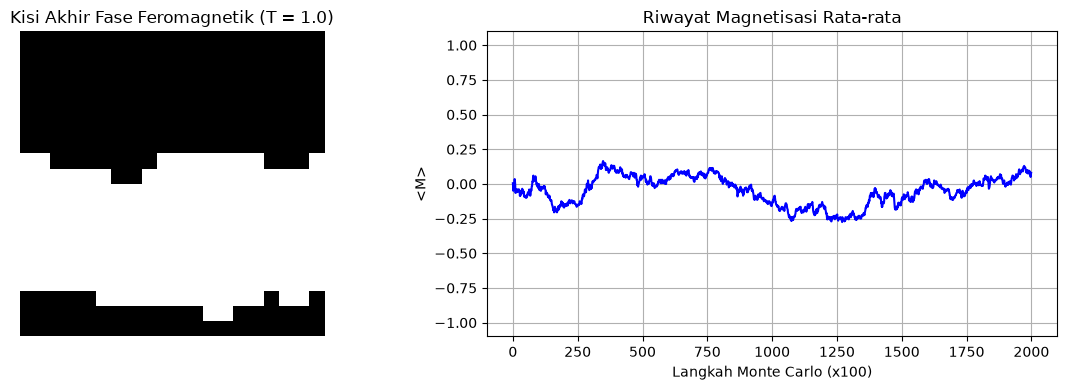

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

def metropolis_step(grid, T):
    N = grid.shape[0]
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    s_neighbors = grid[(x+1)%N, y] + grid[(x-1)%N, y] + grid[x, (y+1)%N] + grid[x, (y-1)%N]
    delta_E = 2 * grid[x, y] * s_neighbors
    if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
        grid[x, y] *= -1
    return grid

# Parameter Kasus 1
GRID_SIZE = 20
TEMPERATURE = 1.0
MONTE_CARLO_STEPS = 200000

grid = np.random.choice([-1, 1], size=(GRID_SIZE, GRID_SIZE))
M_history = []

for step in range(MONTE_CARLO_STEPS):
    grid = metropolis_step(grid, TEMPERATURE)
    if step % 100 == 0:
        M_history.append(np.mean(grid))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f"Kisi Akhir Fase Feromagnetik (T = {TEMPERATURE})")
axes[0].axis('off')
axes[1].plot(M_history, color='blue')
axes[1].set_title("Riwayat Magnetisasi Rata-rata")
axes[1].set_xlabel("Langkah Monte Carlo (x100)")
axes[1].set_ylabel("<M>")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True)
plt.tight_layout()
plt.show()